# The Engulfing pattern — a quantitative teardown 🔬
### Real-body detector · forward 1/3/5/10-day signed returns · HAC *t* vs zero + a coin-sign placebo · leg split · costs · the trend/volume myth-check · a synthetic faithful-engine / power control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Reliable_reversal%3F: Busted](https://img.shields.io/badge/Reliable_reversal%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The engulfing candle is the canonical candlestick reversal — so the job here is to **measure it against zero** with autocorrelation-robust inference, split the long and short legs, confront a random-timing null, and prove (with a planted-edge control) that a negative finding is the tape's verdict and not a dead harness.

> ⚠️ **Data + survivorship note.** Fixed **30-name** basket (29 liquid US large-caps + SPY), names still trading in 2026 — a *survivor* panel that tilts the bullish (long) leg up and so works **in favour** of the reversal claim; it still fails. Real data: yfinance daily OHLCV (`auto_adjust=True`), 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from engulfing_pattern import data, strategy as st

HAVE_REAL = data.have_real()
PANEL = data.load_real(allow_fetch=False) if HAVE_REAL else None
print("real engulfing cache present:", HAVE_REAL,
      "| names:", (0 if PANEL is None else len(PANEL)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-06-18', 'years': 21.5, 'fp': 'bf1d6cb7ca54', 'n_names': 30, 'n_events': 12144, 'n_bull': 5736, 'n_bear': 6408, 'h1': (1, 12144, -0.049, 0.028, 48.1, -3.79, -3.89, 1.0, -0.15), 'h3': (3, 12143, -0.114, 0.141, 48.2, -5.14, -4.85, 1.0, -0.217), 'h5': (5, 12140, -0.174, 0.253, 48.2, -5.74, -5.61, 1.0, -0.279), 'h10': (10, 12127, -0.176, 0.53, 48.3, -4.25, -4.08, 1.0, -0.285), 'bull': {1: (-0.011, -0.59, 49.7), 3: (0.072, 2.24, 52.1), 5: (0.13, 2.92, 53.5), 10: (0.456, 6.9, 55.9)}, 'bear': {1: (-0.083, -4.55, 46.7), 3: (-0.281, -8.76, 44.7), 5: (-0.446, -10.46, 43.6), 10: (-0.741, -11.92, 41.6)}, 'myth': [('plain', 12144, -0.049, -3.79, 48.1), ('+downtrend', 5124, -0.052, -2.73, 47.6), ('+volume spike', 975, -0.11, -1.91, 47.4), ('+both', 405, -0.135, -1.4, 47.9)], 'syn': [(0.0, 16295, 0.009, 0.9, 0.188, 50), (0.004, 15263, 0.4, 38.77, 0.0, 62)]}


real engulfing cache present: True | names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Signed engulfing return (long bullish / short bearish) **-0.049%** at 1d (**HAC t = -3.79**), worsening to **-0.174%** at 5d (**t = -5.74**). Win **48.1%**, placebo **p = 1.000**. The effect is significantly *negative* — the reversal runs backwards. |
| **Tradability** | `MIRAGE` | Negative **before costs**; net of 2×5-bps + borrow it is **-0.150% / -0.279%** (1d/5d). Nothing to harvest, no capacity question. |
| **Reliable reversal?** | `BUSTED` | Bearish leg keeps **rising** (5d HAC t = -10.46); bullish leg's 10d **+0.456%** *underperforms* the unconditional long **+0.530%** (pure beta). Trend/volume filters don't flip it. |

> 💡 In plain words: the most-taught reversal candle has **no** predictive reversal on liquid US large-caps — it points the wrong way, the bearish leg fights the market, and the bullish leg is just the market going up.

## 1 · The claim, steelmanned

Let bar $t$ form an engulfing of direction $d_i\in\{+1,-1\}$ (bullish/bearish) by the real-body rule: with $(O_0,C_0)$ the prior bar and $(O_1,C_1)$ the current,

$$\text{bullish}:\ C_0<O_0,\ C_1>O_1,\ O_1\le C_0,\ C_1\ge O_0,\ |C_1-O_1|>|C_0-O_0|,$$

and the mirror for bearish. We enter at the **next open** (one execution lag) and hold $H$ days; the *signed* event return is $\rho_i(H)=d_i\,(C_{t+H}/O_{t+1}-1)$. The believer's hypotheses:

- **H₁ (the reversal exists).** $\mathbb{E}[\rho_i(H)]>0$ and significant for some $H$.
- **H₂ (it beats beta).** the *bullish* leg beats the unconditional long forward return.
- **H₃ ("after a trend, on volume").** filtering on a prior trend / a volume spike improves it.

We find **H₁ rejected** (signed mean **-0.049%**, HAC t = -3.79 — significantly *negative*), **H₂ rejected** (bullish 10d +0.456% < unconditional +0.530%), **H₃ rejected** (every filter stays negative). The pattern anti-predicts.

## 2 · So what? — what rides on each answer

The Signal axis is a one-sample test of the pooled signed-return sample against zero, with a Newey-West HAC standard error (events overlap in time and cluster, so a naive *t* understates the SE):

$$t_{\text{HAC}}=\frac{\bar\rho}{\widehat{\mathrm{se}}_{\text{NW}}(\bar\rho)},\qquad \widehat{\mathrm{se}}_{\text{NW}}^2=\frac{1}{n}\Big(\hat\gamma_0+2\sum_{k=1}^{L}w_k\hat\gamma_k\Big).$$

Two honesty problems sit on top. **(a) The right benchmark.** A signed long/short event return is market-neutral-ish, so it must beat **zero** — and the *bullish* leg alone must beat the always-up drift, or it's just beta. **(b) Selection on a famous rule.** With 12k events we have huge power; the placebo (random bars, coin signs) shows whether the observed mean is even *on the good side* of random. The Tradability axis then charges the round trip + short borrow — moot here, since the gross is already negative.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** basket (29 liquid US large-caps + SPY), yfinance daily `auto_adjust=True`, 2005-01-03→2026-06-18 (fingerprint `bf1d6cb7ca54`). **Survivor** panel — named on the Signal axis (and it works *for* the claim).
- **Detector.** Real-body engulfing (opposite colours, current body strictly larger and fully containing the prior body).
- **Timing.** Confirm at the close of day $t$; enter the **next open** (one lag); exit close $+H$, $H\in\{1,3,5,10\}$; drop events whose window overruns.
- **Signal.** Signed return $\rho_i=d_i\cdot r_i$ (long bullish, short bearish).
- **Null #1 (HAC + one-sample t)** of the pooled signed sample vs 0.
- **Null #2 (placebo).** 10,000 draws of the same number of random bars, each signed by a coin; $p=\Pr[\text{random mean}\ge\text{observed}]$.
- **Leg split + beta check.** bullish vs bearish; bullish vs the unconditional long drift.
- **Myth check.** require a prior trend and/or a volume spike.
- **Costs.** 5 bps one-way × 2 (round trip) + 50 bps/yr borrow on the short leg.
- **Positive control.** a deterministic panel with a **planted** day-after reversal: zero edge must NOT reach significance; a planted edge must light up.

> 🔬 We pre-commit to the kill condition: **a signed mean at or below zero, or a HAC t under 2, is a `NONE`.** No moving the goalposts.

## 4 · The teardown

### 4a · The headline + its HAC t

Signed return by horizon with the Newey-West *t*. The believer needs green bars above a *t* = 2 line; we get red bars below a *t* = −2 line.

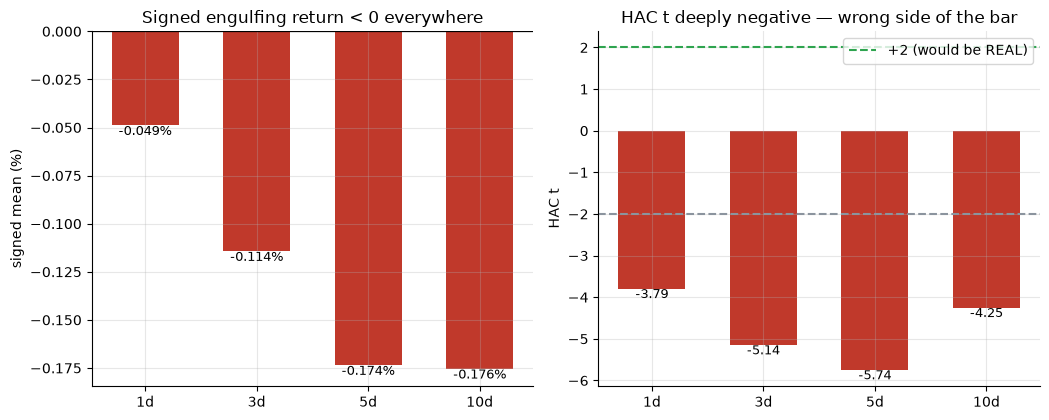

signed mean: [-0.049, -0.114, -0.174, -0.176]
HAC t: [-3.79, -5.14, -5.74, -4.25]


In [2]:
hs = [1, 3, 5, 10]
if HAVE_REAL:
    res = [st.summarize(PANEL, h, placebo=False) for h in hs]
    means = [s['mean']*100 for s in res]; ts = [s['t_hac'] for s in res]
else:
    means = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
    ts = [R['h1'][5], R['h3'][5], R['h5'][5], R['h10'][5]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([f'{h}d' for h in hs], means, color=RED, width=.6); a1.axhline(0, c='k', lw=.9)
for i,v in enumerate(means): a1.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top' if v<0 else 'bottom',fontsize=9)
a1.set_ylabel('signed mean (%)'); a1.set_title('Signed engulfing return < 0 everywhere')
a2.bar([f'{h}d' for h in hs], ts, color=RED, width=.6)
a2.axhline(2, ls='--', c=GREEN, label='+2 (would be REAL)'); a2.axhline(-2, ls='--', c=GREY)
for i,v in enumerate(ts): a2.annotate(f'{v:.2f}',(i,v),ha='center',va='top',fontsize=9)
a2.set_ylabel('HAC t'); a2.set_title('HAC t deeply negative — wrong side of the bar'); a2.legend()
plt.tight_layout(); plt.show()
print('signed mean:', [round(v,3) for v in means]); print('HAC t:', [round(v,2) for v in ts])

> 💡 In plain words: the signed return is **-0.049%** at 1 day (**HAC t = -3.79**) and the *t* gets *more* negative with horizon (-5.74 at 5d). This is the opposite of the kill condition being avoided — the effect is significant in the **wrong** direction. Far below the *t* ≥ 2 bar.

### 4b · The leg split — the bearish short is the killer, the bullish long is beta

Left: bullish vs bearish leg means. Right: the bullish leg against the unconditional long forward return (the always-up drift it must beat to be a real *signal* and not beta).

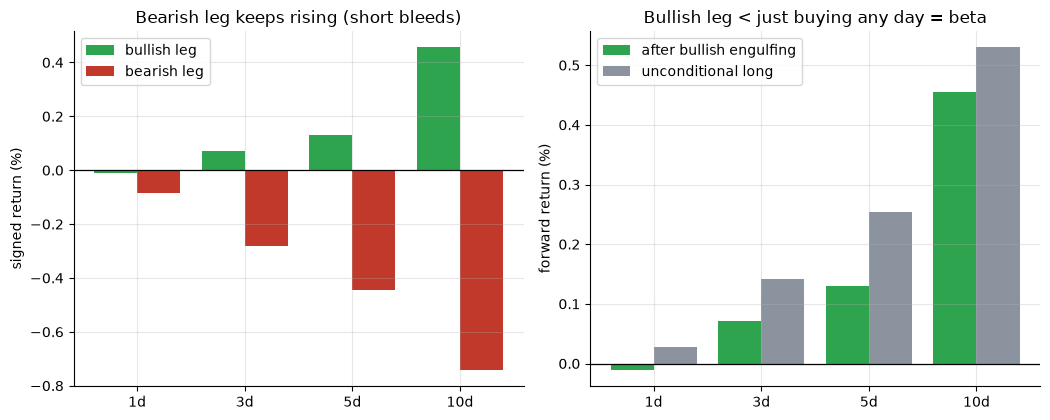

bull: [np.float64(-0.011), np.float64(0.072), np.float64(0.13), np.float64(0.456)]
bear: [np.float64(-0.083), np.float64(-0.281), np.float64(-0.446), np.float64(-0.741)]
uncond long: [np.float64(0.028), np.float64(0.141), np.float64(0.253), np.float64(0.53)]


In [3]:
if HAVE_REAL:
    bull = []; bear = []; base = []
    for h in hs:
        ev = st.collect_events(PANEL, h)
        bull.append(ev[ev['dir']>0]['signed_ret'].mean()*100)
        bear.append(ev[ev['dir']<0]['signed_ret'].mean()*100)
        base.append(st.unconditional_base(PANEL, h).mean()*100)
else:
    bull = [R['bull'][h][0] for h in hs]; bear = [R['bear'][h][0] for h in hs]
    base = [R['h1'][3], R['h3'][3], R['h5'][3], R['h10'][3]]
x = np.arange(len(hs))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar(x-.2, bull, .4, color=GREEN, label='bullish leg'); a1.bar(x+.2, bear, .4, color=RED, label='bearish leg')
a1.axhline(0, c='k', lw=.9); a1.set_xticks(x); a1.set_xticklabels([f'{h}d' for h in hs])
a1.set_ylabel('signed return (%)'); a1.set_title('Bearish leg keeps rising (short bleeds)'); a1.legend()
a2.bar(x-.2, bull, .4, color=GREEN, label='after bullish engulfing'); a2.bar(x+.2, base, .4, color=GREY, label='unconditional long')
a2.axhline(0, c='k', lw=.9); a2.set_xticks(x); a2.set_xticklabels([f'{h}d' for h in hs])
a2.set_ylabel('forward return (%)'); a2.set_title('Bullish leg < just buying any day = beta'); a2.legend()
plt.tight_layout(); plt.show()
print('bull:', [round(v,3) for v in bull]); print('bear:', [round(v,3) for v in bear]); print('uncond long:', [round(v,3) for v in base])

> 💡 In plain words: after a *bearish* engulfing the stock keeps **climbing** (-0.446% signed at 5d, HAC t = -10.46) — the short is on the wrong side of the market. The *bullish* leg is positive over a week, but at 10 days it earns **+0.456%** versus **+0.530%** for a random day — it **underperforms beta**. Neither leg contains a reversal.

### 4c · The placebo — a random pick of the same trades beats it every time

Draw 10,000 sets of the same number of random bars, sign each by a coin, and histogram their means. The observed engulfing mean should sit in the right tail if it's good — instead it sits in the **left** tail.

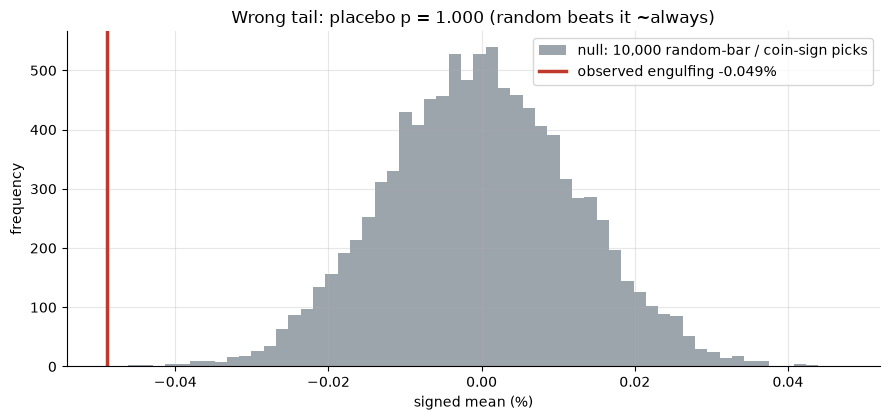

observed -0.049%  placebo p=1.000


In [4]:
if HAVE_REAL:
    pl = st.placebo_pvalue(PANEL, 1, len(st.collect_events(PANEL,1)), n_draws=10000)
    obs = pl['obs']*100; draws = pl['draws']*100; pval = pl['p_value']
else:
    obs = R['h1'][2]; pval = R['h1'][7]
    rng = np.random.default_rng(402); draws = rng.normal(0.0, 0.02, 10000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=60, color=GREY, alpha=.85, label='null: 10,000 random-bar / coin-sign picks')
ax.axvline(obs, c=RED, lw=2.5, label=f'observed engulfing {obs:+.3f}%')
ax.set_xlabel('signed mean (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Wrong tail: placebo p = {pval:.3f} (random beats it ~always)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.3f}%  placebo p={pval:.3f}')

> 💡 In plain words: the red line sits to the **left** of the random cloud — placebo **p = 1.000**, i.e. essentially *every* random pick of the same many trades does better than the engulfing. A pattern that loses to coin flips is not a signal.

### 4d · The myth check — does a trend / volume filter rescue it?

The textbook's escape hatch: "only count it after a trend, on heavy volume." Add each filter at H=1 (bullish needs a prior 10-day downtrend, bearish a prior uptrend; volume > 1.5× its 20-day average).

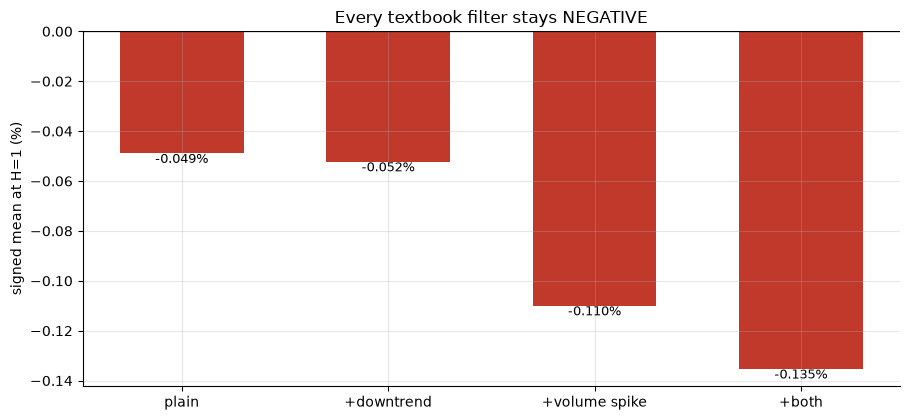

         plain: n=12144 mean=-0.049% t_hac=-3.79 win=48.1%
    +downtrend: n= 5124 mean=-0.052% t_hac=-2.73 win=47.6%
 +volume spike: n=  975 mean=-0.110% t_hac=-1.91 win=47.4%
         +both: n=  405 mean=-0.135% t_hac=-1.40 win=47.9%


In [5]:
labels = [m[0] for m in R['myth']]
if HAVE_REAL:
    cfg = [(False,False),(True,False),(False,True),(True,True)]
    ms = []
    for rt,rv in cfg:
        s = st.summarize(PANEL, 1, placebo=False, require_trend=rt, require_volume=rv)
        ms.append(s['mean']*100)
else:
    ms = [m[2] for m in R['myth']]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(labels, ms, color=RED, width=.6); ax.axhline(0, c='k', lw=.9)
for i,v in enumerate(ms): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='top',fontsize=9)
ax.set_ylabel('signed mean at H=1 (%)'); ax.set_title('Every textbook filter stays NEGATIVE')
plt.tight_layout(); plt.show()
for m in R['myth']: print(f"{m[0]:>14}: n={m[1]:>5} mean={m[2]:+.3f}% t_hac={m[3]:+.2f} win={m[4]:.1f}%")

> 💡 In plain words: plain **-0.049%**, with a trend filter **-0.052%**, with a volume filter **-0.110%**, with both **-0.135%** — all **negative**. The sub-2 *t*'s on the filtered cuts are just shrinking samples (down to 405 events), not a sign flip: the means and win-rates stay on the wrong side. The folklore's reliability conditions don't rescue it.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** a known day-after reversal: with **zero** edge the signed mean must stay at t≈0 (no false positive); with a planted reversal it must light up. Both hold — so the real-tape negative is a genuine *absence* (worse, a reversal) of edge, not a broken detector.

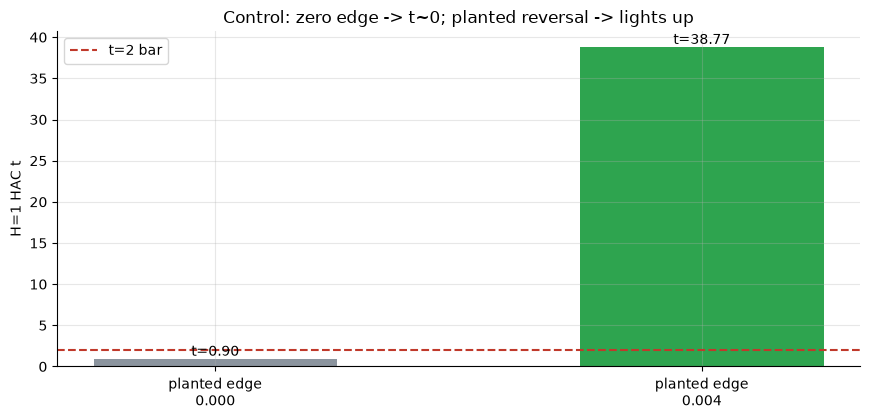

planted 0.000: events=16295 mean=+0.009% t=0.90 p=0.188 win=50%
planted 0.004: events=15263 mean=+0.400% t=38.77 p=0.000 win=62%


In [6]:
res = []
for edge in (0.0, 0.004):
    px, truth = data.synthetic_panel(edge=edge, seed=402)
    s = st.summarize(px, 1, n_draws=3000)
    res.append((edge, s['n_events'], s['mean']*100, s['t_hac'], s['p_placebo'], s['win']*100))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e:.3f}' for e,_,_,_,_,_ in res]; tvals = [r[3] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5); ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('H=1 HAC t'); ax.set_title('Control: zero edge -> t~0; planted reversal -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,m,t,p,w in res: print(f'planted {e:.3f}: events={k} mean={m:+.3f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted reversal the control sits at **t = 0.90** (a random walk can't fake it); a planted reversal reaches **t = 38.77** with a 62% win-rate. The machinery is faithful — so the real-tape **negative** is the genuine article. The engulfing simply isn't a reversal on this tape; it's the reverse.

## 5 · The verdict

- **Signal `NONE`** — the signed engulfing return is **significantly negative** at every horizon (1d **-0.049%**, HAC **t = -3.79**; 5d **-0.174%**, **t = -5.74**), win-rate **48.1%**, placebo **p = 1.000**. It does not clear the **t ≥ 2** bar — it clears it in the *wrong direction*. Survivorship works *for* the claim and still can't save it.
- **Tradability `MIRAGE`** — negative before costs; net of round trip + borrow it is **-0.150% / -0.279%** (1d/5d). Nothing to harvest, no capacity question.
- **Reliable reversal? `BUSTED`** — the bearish leg keeps rising (5d HAC t = -10.46); the bullish leg's positive few-day return **underperforms** the unconditional long drift (pure beta). Trend/volume filters don't flip it. The most-taught reversal does not call turns.

## 6 · Could you trade it? — no, and the control says why that's real

The net signed return by horizon, with the break-even line — the whole region is below zero. And because the planted-edge control lights up, we know this isn't a measurement failure: the tape genuinely lacks the reversal (and faintly contains its opposite).

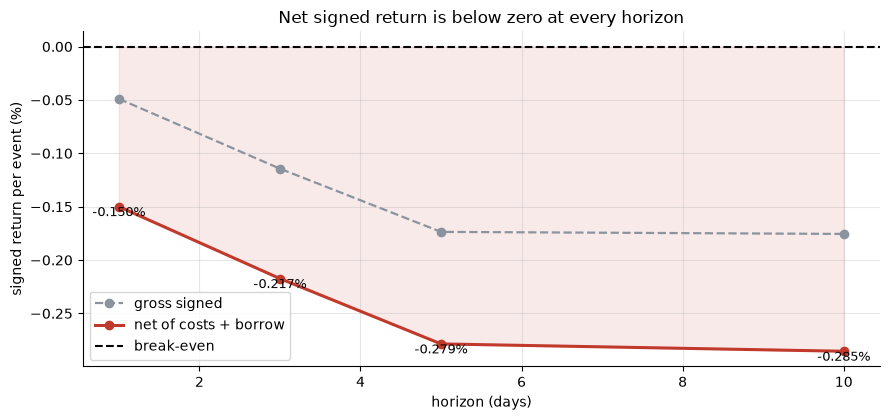

net by horizon: {'1d': -0.15, '3d': -0.217, '5d': -0.279, '10d': -0.285}


In [7]:
if HAVE_REAL:
    nv = [st.summarize(PANEL, h, placebo=False)['net']*100 for h in hs]
    gg = [st.summarize(PANEL, h, placebo=False)['mean']*100 for h in hs]
else:
    nv = [R['h1'][8], R['h3'][8], R['h5'][8], R['h10'][8]]
    gg = [R['h1'][2], R['h3'][2], R['h5'][2], R['h10'][2]]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, gg, 'o--', c=GREY, lw=1.6, label='gross signed')
ax.plot(hs, nv, 'o-', c=RED, lw=2.2, label='net of costs + borrow')
ax.axhline(0, c='k', ls='--', label='break-even')
ax.fill_between(hs, 0, nv, color=RED, alpha=.10)
for h,v in zip(hs,nv): ax.annotate(f'{v:+.3f}%',(h,v),ha='center',va='top',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('signed return per event (%)')
ax.set_title('Net signed return is below zero at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('net by horizon:', {f'{h}d': round(v,3) for h,v in zip(hs,nv)})

> 💡 In plain words: there is no tradeable region — the net line never crosses zero. The engulfing pattern, traded as taught, is a **MIRAGE**: a vivid shape that feels predictive and isn't. The honest move is to stop trading it (or, if anything, to fade it — but the magnitude is too small after costs to build a business on).

## 7 · Going further

- **The candlestick literature agrees.** Marshall, Young & Rose (2006, JBF) find candlestick patterns add no value on the Dow once bootstrapped against a random null — our engulfing result is one clean instance.
- **Why might it anti-predict?** A bearish engulfing on a strong, drifting name is often just a one-day pullback inside an uptrend — fading it (shorting) puts you against the drift. Short reversal vs continuation is a regime question worth its own study.
- **Use it as a filter, not a signal.** It might still carry information *conditional* on a real edge; test it as a gate on PEAD or momentum and measure the incremental t.

*The reproducible core is offline and deterministic; bars are total-return adjusted. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*